In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Load the dataset
df = pd.read_csv('wine.csv')
X = df.drop('Type', axis=1)

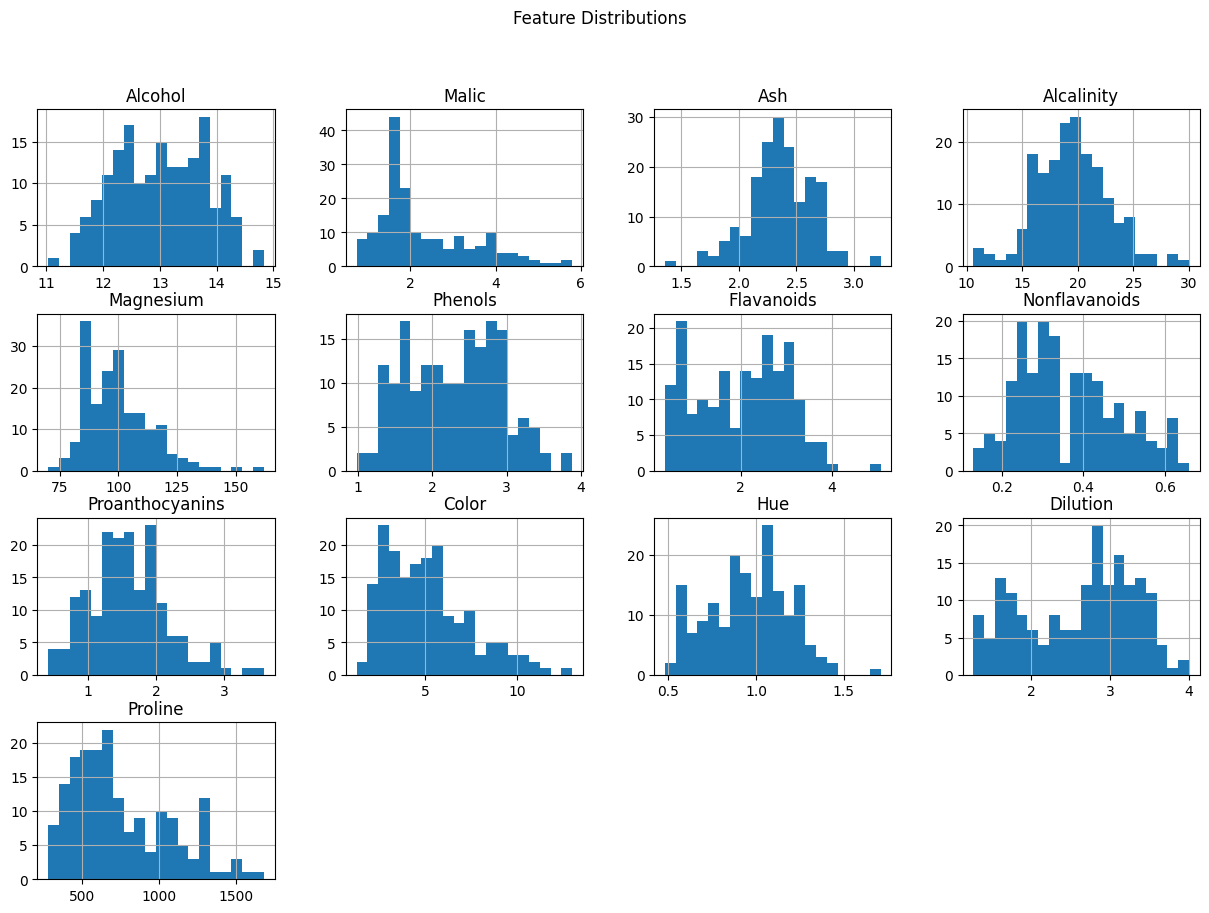

In [4]:
# Visualizing distributions
X.hist(bins=20, figsize=(15, 10))
plt.suptitle('Feature Distributions')
plt.show()

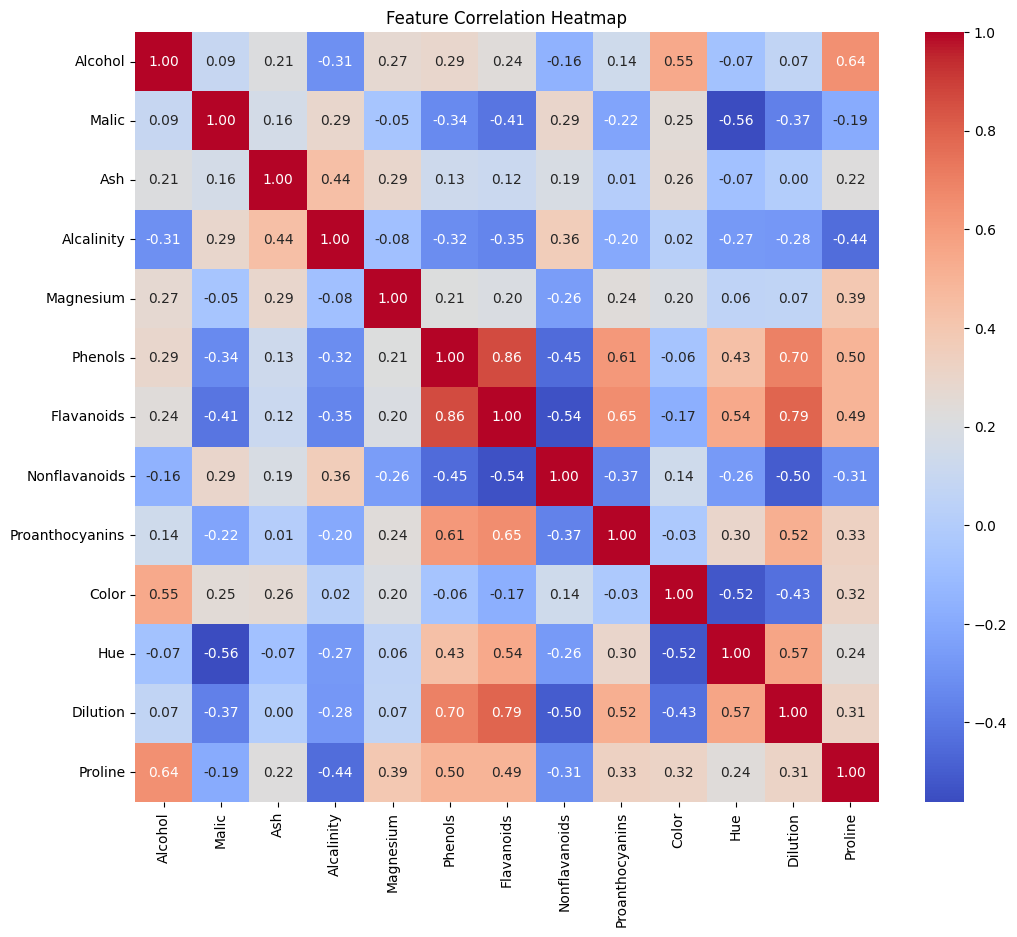

In [5]:
# Investigating correlations
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# PCA implementation
pca = PCA()
pca_values = pca.fit_transform(X_scaled)

# Variance analysis
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(np.round(var_ratio, decimals=4)*100)

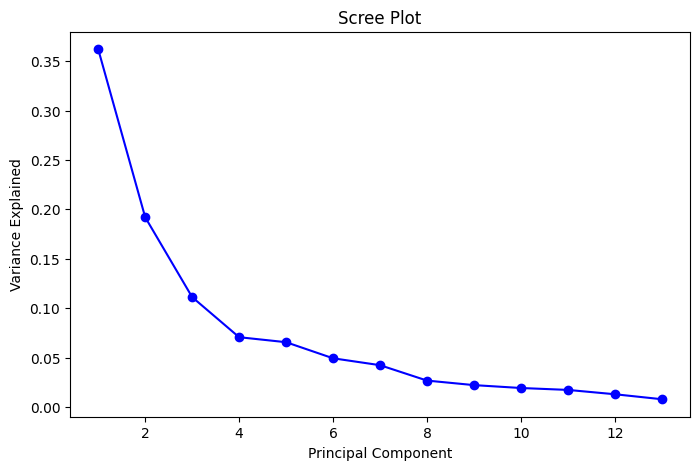

In [8]:
# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_ratio)+1), var_ratio, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [9]:
X_pca = pca_values[:, :3]

In [10]:
wcss_orig = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss_orig.append(kmeans.inertia_)

# Selecting k=3 (standard for this dataset)
kmeans_orig = KMeans(n_clusters=3, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)
sil_orig = silhouette_score(X_scaled, labels_orig)
print(f"Silhouette Score (Original Data): {sil_orig:.4f}")

Silhouette Score (Original Data): 0.2849


In [11]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)
print(f"Silhouette Score (PCA Data): {sil_pca:.4f}")

Silhouette Score (PCA Data): 0.4538


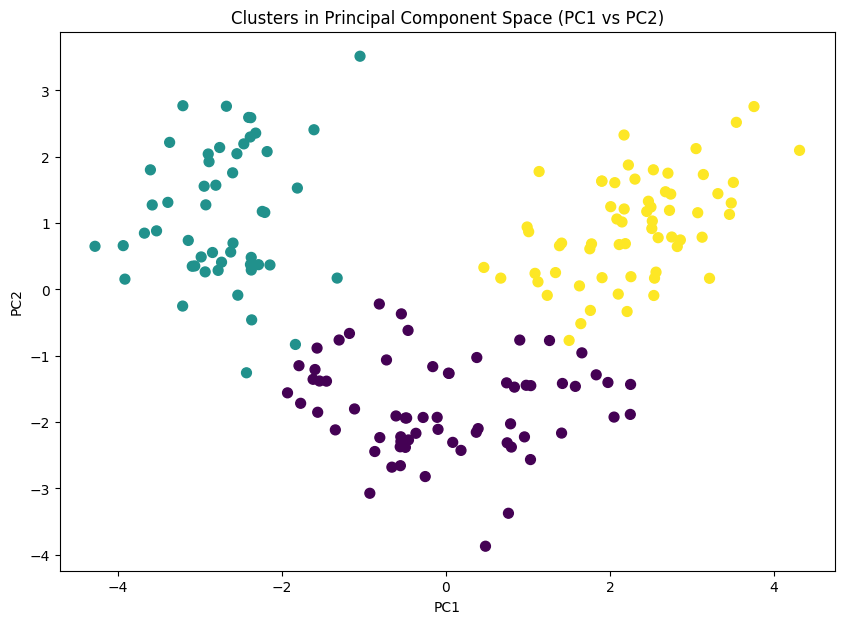

In [12]:
# Visualization of PCA Clusters
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', s=50)
plt.title('Clusters in Principal Component Space (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()